The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


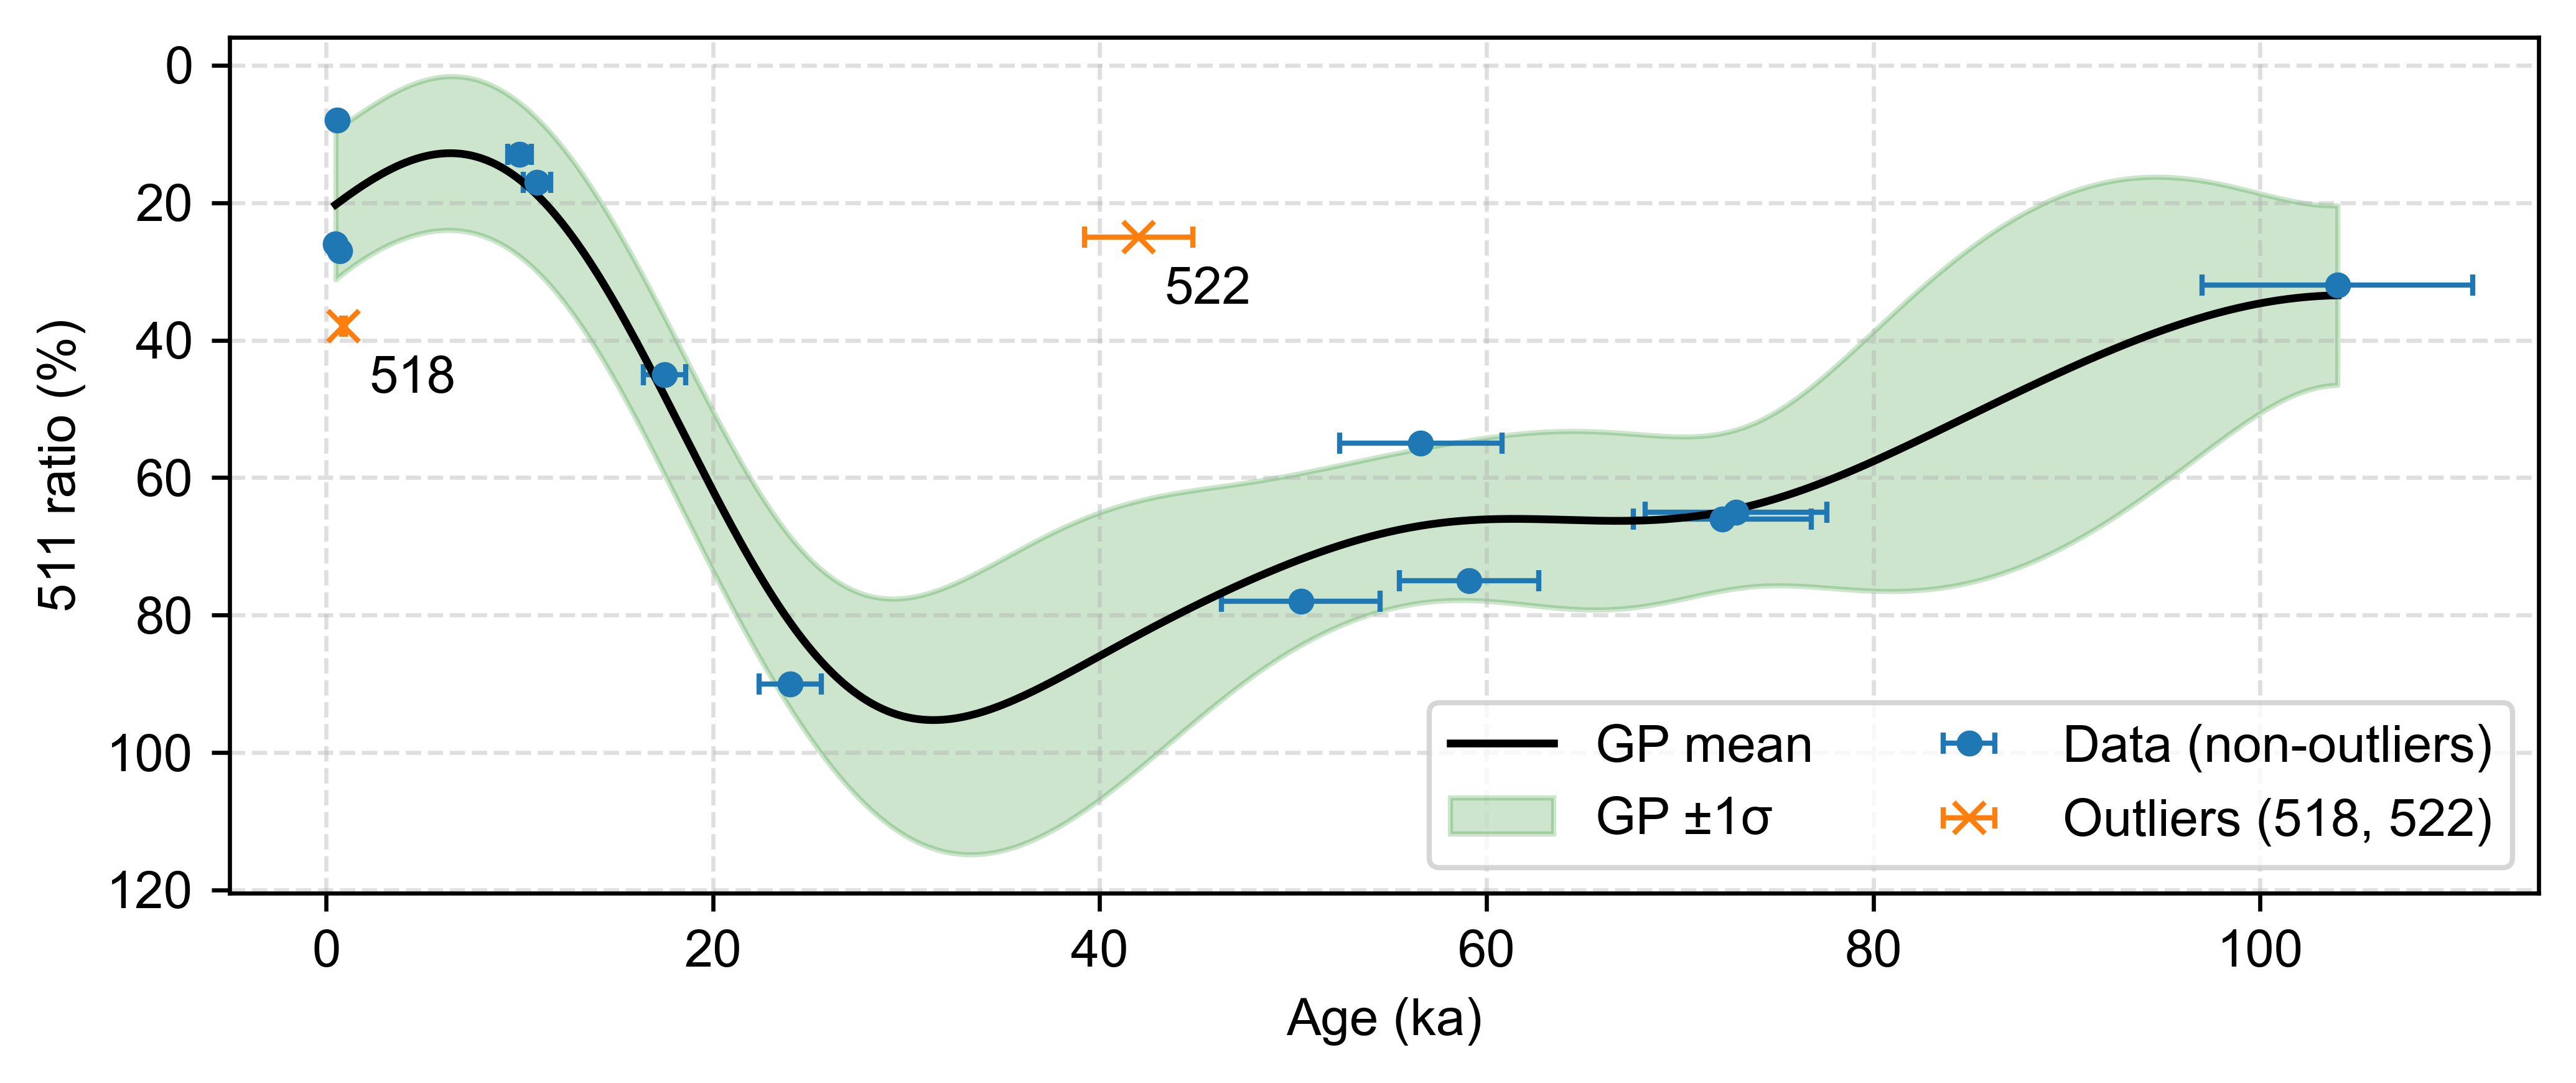

In [9]:
# Re-run after environment reset (the notebook was cleared).

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans"]
plt.rcParams["mathtext.default"] = "regular"

data = [
    ["T1","CSC-1A","CSC-1(512)",0.49,0.06,26],
    ["T1","JSL-2A","JSL-2A(513)",0.71,0.07,27],
    ["T1","JSL-3A","JSL-3A(514)",0.56,0.07,8],
    ["T2","CBR-1A","CBR-1A(511)",24,1.6,90],
    ["T2","CSC-2A","CSC-2A(515)",17.5,1.1,45],
    ["T2","CSC-3A","CSC-3A(516)",10,0.6,13],
    ["T2","CSC-4A","CSC-4A(517)",10.9,0.7,17],
    ["T2","CSC-5A","CSC-5A(518)",0.9,0.09,38],
    ["T3","KXC-3A","KXC-3A(522)",42,2.8,25],
    ["T3","RJG-1A","RJG-1A(523)",59.1,3.6,75],
    ["T3","HDL-1A","HDL-1A(524)",50.4,4.1,78],
    ["T3","JD-1A","JD-1A(526)",72.2,4.6,66],
    ["T3","JD-2A","JD-2A(527)",72.9,4.7,65],
    ["T3","ALL-1A","ALL-1A(529)",56.6,4.2,55],
    ["T3","MS-1A","MS-1A(530)",104,7,32],
]
columns = ["Geomorphic unit","ID","Lab ID","age(ka)","1 sigma","511 ratio (%)"]
df = pd.DataFrame(data, columns=columns)

def extract_numeric_lab_id(s):
    m = re.search(r"\((\d+)\)", s)
    return int(m.group(1)) if m else None

df["Lab_ID_num"] = df["Lab ID"].apply(extract_numeric_lab_id)

# Mark outliers by lab ID number
outlier_ids = {518, 522}
df["is_outlier"] = df["Lab_ID_num"].isin(outlier_ids)

# Data for GP fitting (exclude outliers); GP uses X only (no x-uncertainty)
df_fit = df.loc[~df["is_outlier"]].copy().sort_values("age(ka)")
X = df_fit[["age(ka)"]].values
y = df_fit["511 ratio (%)"].values

# Standardize X for GP only
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

# Kernel and GP
kernel = (ConstantKernel(1.0, (1e-2, 1e3)) *
          RBF(length_scale=1, length_scale_bounds=(1e-2, 1e3))
          + WhiteKernel(noise_level=1, noise_level_bounds=(1e-6, 1e2)))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                              n_restarts_optimizer=12, random_state=0)
gp.fit(Xs, y)

# Prediction grid in age space of the *non-outlier* data
x_grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
xg_s = scaler.transform(x_grid)
y_mean, y_std = gp.predict(xg_s, return_std=True)

# Split outliers
df_out = df.loc[df["is_outlier"]]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(7, 3), dpi=600)

# Non-outliers with horizontal error bars (age ± 1σ)
ax.errorbar(
    df_fit["age(ka)"].values,
    df_fit["511 ratio (%)"].values,
    xerr=df_fit["1 sigma"].values,
    fmt="o",
    ms=4,
    lw=1.0,
    capsize=2,
    elinewidth=1.0,
    label="Data (non-outliers)"
)

# Outliers with horizontal error bars (age ± 1σ)
ax.errorbar(
    df_out["age(ka)"].values,
    df_out["511 ratio (%)"].values,
    xerr=df_out["1 sigma"].values,
    fmt="x",
    ms=6,
    lw=1.0,
    capsize=2,
    elinewidth=1.0,
    label="Outliers (518, 522)"
)

# GP mean and ±1σ band (note: band alpha may warn for EPS; keep as-is unless you prefer solid)
ax.plot(x_grid.ravel(), y_mean, label="GP mean", color="k")
band = ax.fill_between(x_grid.ravel(), y_mean - y_std, y_mean + y_std, color='green',
                       alpha=0.2, label="GP ±1σ")

# Annotate outlier lab IDs next to their points
for _, row in df_out.iterrows():
    ax.annotate(str(row["Lab_ID_num"]),
                (row["age(ka)"], row["511 ratio (%)"]),
                xytext=(5, -12.8), textcoords="offset points")

ax.set_xlabel("Age (ka)")
ax.set_ylabel("511 ratio (%)")
ax.invert_yaxis()
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="lower right", ncol=2)

# Avoid clipping the 104 ka point
xmin = -5
xmax = float(df["age(ka)"].max() * 1.1)
ax.set_xlim([xmin, xmax])

plt.tight_layout()

out_dir = "Figures"
os.makedirs(out_dir, exist_ok=True)
jpg_path = os.path.join(out_dir, "511_ratio_GP.jpg")
pdf_path = os.path.join(out_dir, "511_ratio_GP.pdf")
eps_path = os.path.join(out_dir, "511_ratio_GP.eps")

fig.savefig(jpg_path, dpi=600)
fig.savefig(pdf_path, dpi=600)
fig.savefig(eps_path, dpi=600)

plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


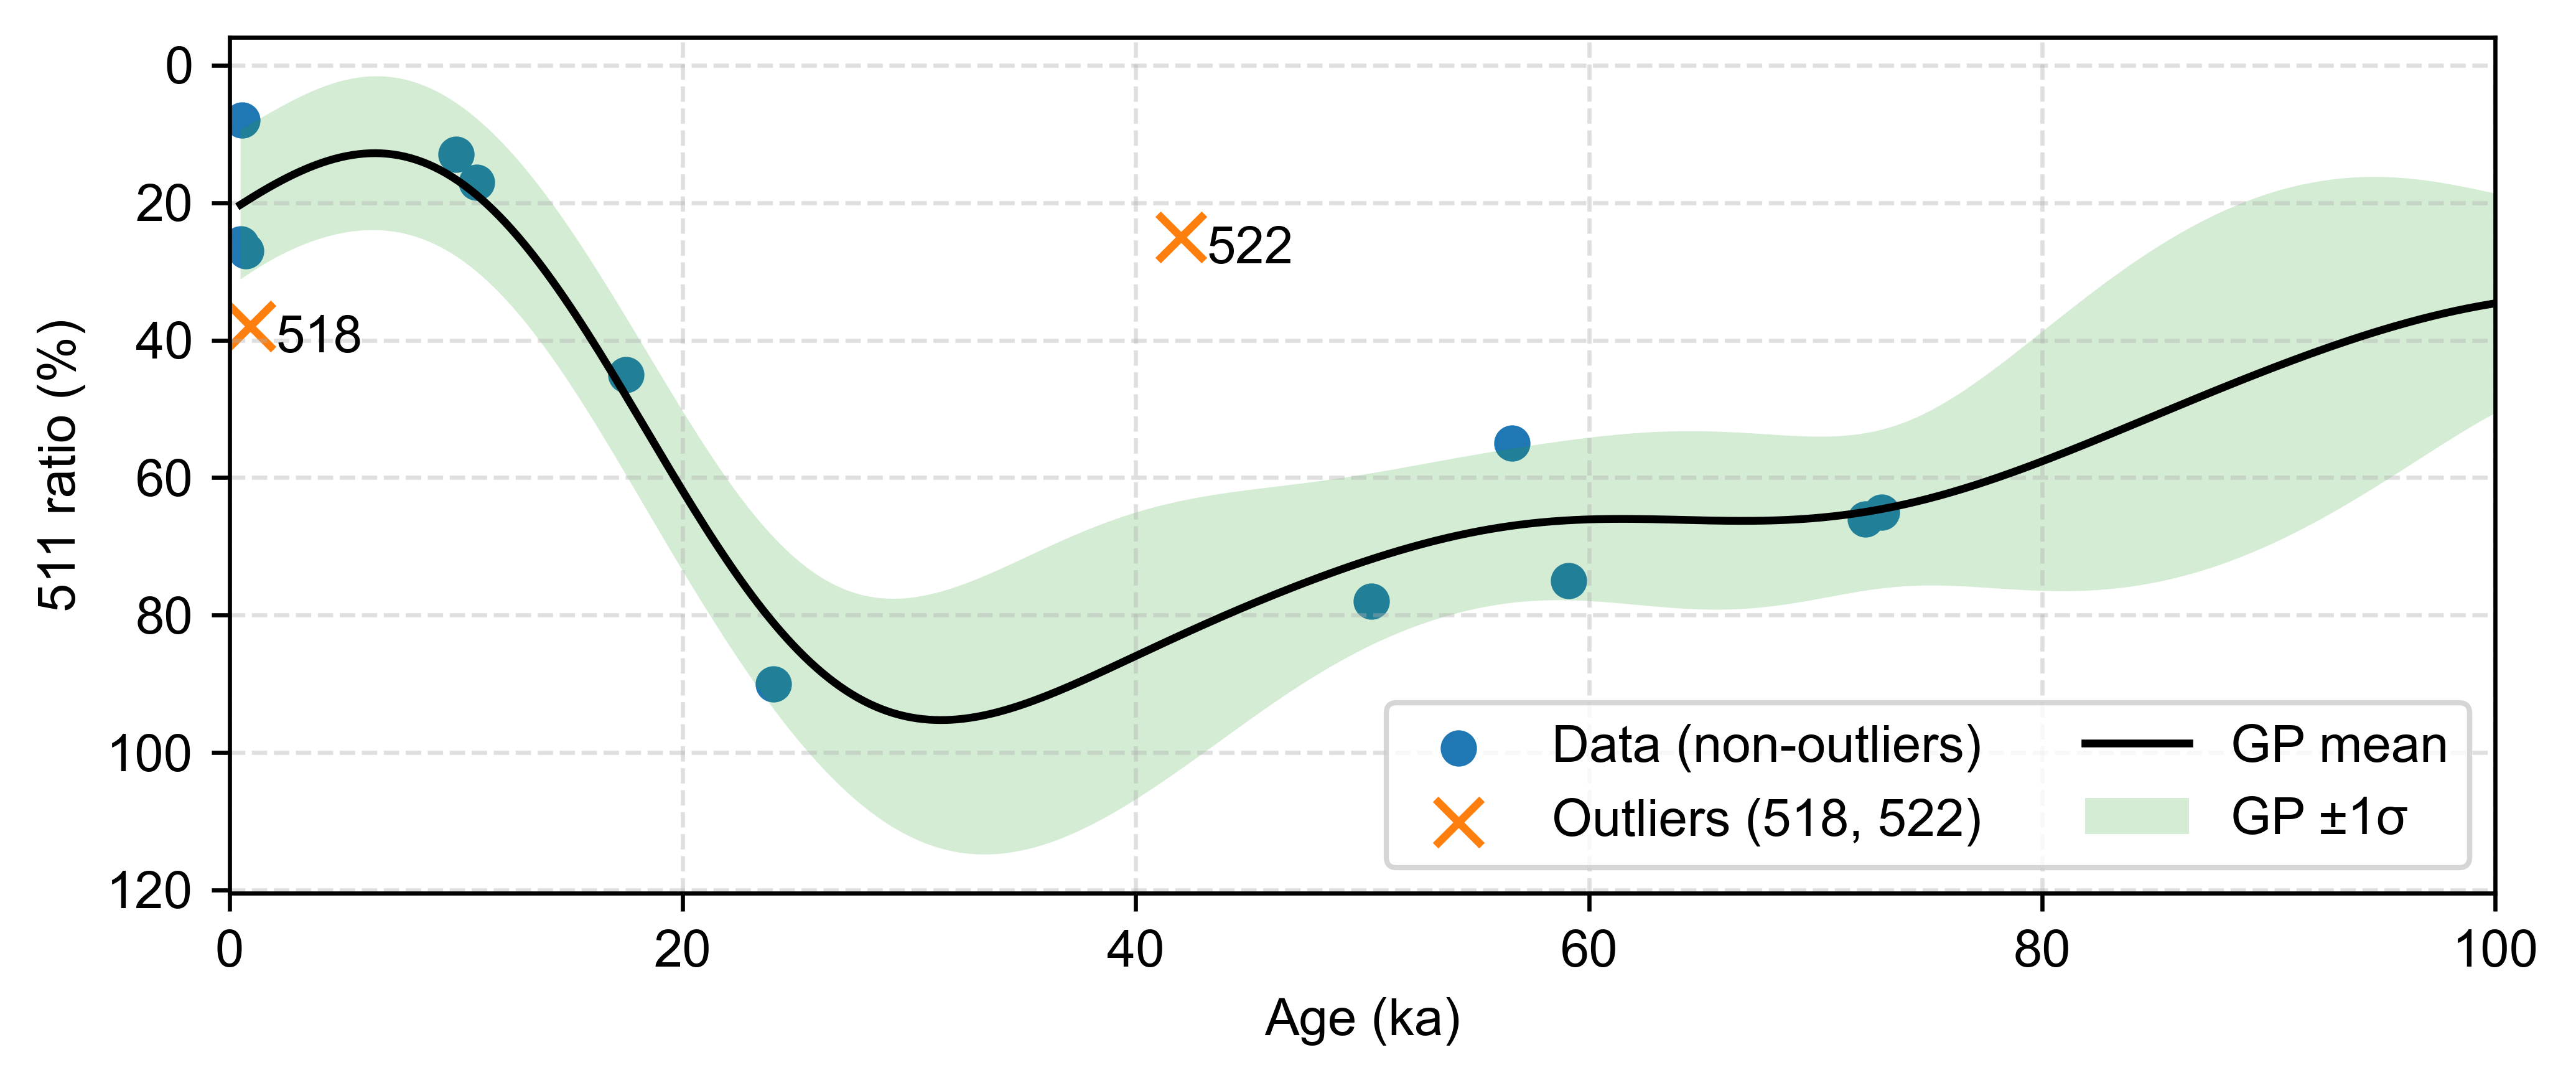

('Figures/511_ratio_GP.jpg',
 'Figures/511_ratio_GP.pdf',
 'Figures/511_ratio_GP.eps')

In [30]:
# Re-run after environment reset (the notebook was cleared).

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans"]
plt.rcParams["mathtext.default"] = "regular"

data = [
    ["T1","CSC-1A","CSC-1(512)",0.49,0.06,26],
    ["T1","JSL-2A","JSL-2A(513)",0.71,0.07,27],
    ["T1","JSL-3A","JSL-3A(514)",0.56,0.07,8],
    ["T2","CBR-1A","CBR-1A(511)",24,1.6,90],
    ["T2","CSC-2A","CSC-2A(515)",17.5,1.1,45],
    ["T2","CSC-3A","CSC-3A(516)",10,0.6,13],
    ["T2","CSC-4A","CSC-4A(517)",10.9,0.7,17],
    ["T2","CSC-5A","CSC-5A(518)",0.9,0.09,38],
    ["T3","KXC-3A","KXC-3A(522)",42,2.8,25],
    ["T3","RJG-1A","RJG-1A(523)",59.1,3.6,75],
    ["T3","HDL-1A","HDL-1A(524)",50.4,4.1,78],
    ["T3","JD-1A","JD-1A(526)",72.2,4.6,66],
    ["T3","JD-2A","JD-2A(527)",72.9,4.7,65],
    ["T3","ALL-1A","ALL-1A(529)",56.6,4.2,55],
    ["T3","MS-1A","MS-1A(530)",104,7,32],
]
columns = ["Geomorphic unit","ID","Lab ID","age(ka)","1 sigma","511 ratio (%)"]
df = pd.DataFrame(data, columns=columns)

def extract_numeric_lab_id(s):
    m = re.search(r"\((\d+)\)", s)
    return int(m.group(1)) if m else None

df["Lab_ID_num"] = df["Lab ID"].apply(extract_numeric_lab_id)
outlier_ids = {518, 522}
df["is_outlier"] = df["Lab_ID_num"].isin(outlier_ids)

df_fit = df.loc[~df["is_outlier"]].copy().sort_values("age(ka)")
X = df_fit[["age(ka)"]].values
y = df_fit["511 ratio (%)"].values

scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF(length_scale=1, length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1, noise_level_bounds=(1e-6, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=12, random_state=0)
gp.fit(Xs, y)

x_grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
xg_s = scaler.transform(x_grid)
y_mean, y_std = gp.predict(xg_s, return_std=True)

df_out = df.loc[df["is_outlier"]]

fig, ax = plt.subplots(figsize=(7, 3), dpi=600)
ax.scatter(df_fit["age(ka)"], df_fit["511 ratio (%)"], marker="o", label="Data (non-outliers)")
ax.scatter(df_out["age(ka)"], df_out["511 ratio (%)"], marker="x", s=80, label="Outliers (518, 522)")
ax.plot(x_grid.ravel(), y_mean, label="GP mean", color='k')
band=ax.fill_between(x_grid.ravel(), y_mean - y_std, y_mean + y_std, alpha=0.2, label="GP ±1σ")

for _, row in df_out.iterrows():
    ax.annotate(str(row["Lab_ID_num"]), (row["age(ka)"], row["511 ratio (%)"]), xytext=(5, -5), textcoords="offset points")

ax.set_xlabel("Age (ka)")
ax.set_ylabel("511 ratio (%)")
ax.invert_yaxis()
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc='lower right', ncol=2)
# set x lim
ax.set_xlim([0,100])

plt.tight_layout()

out_dir = "Figures"
os.makedirs(out_dir, exist_ok=True)
jpg_path = os.path.join(out_dir, "511_ratio_GP.jpg")
pdf_path = os.path.join(out_dir, "511_ratio_GP.pdf")
eps_path = os.path.join(out_dir, "511_ratio_GP.eps")

fig.savefig(jpg_path, dpi=600)
fig.savefig(pdf_path, dpi=600)
fig.savefig(eps_path, dpi=600)

# band.set_alpha(1.0)
# band.set_facecolor((0.85, 0.85, 0.85))   # light gray; adjust if you prefer
# band.set_edgecolor("none")

# fig.savefig(eps_path, dpi=600, format="eps")

plt.show()

jpg_path, pdf_path, eps_path


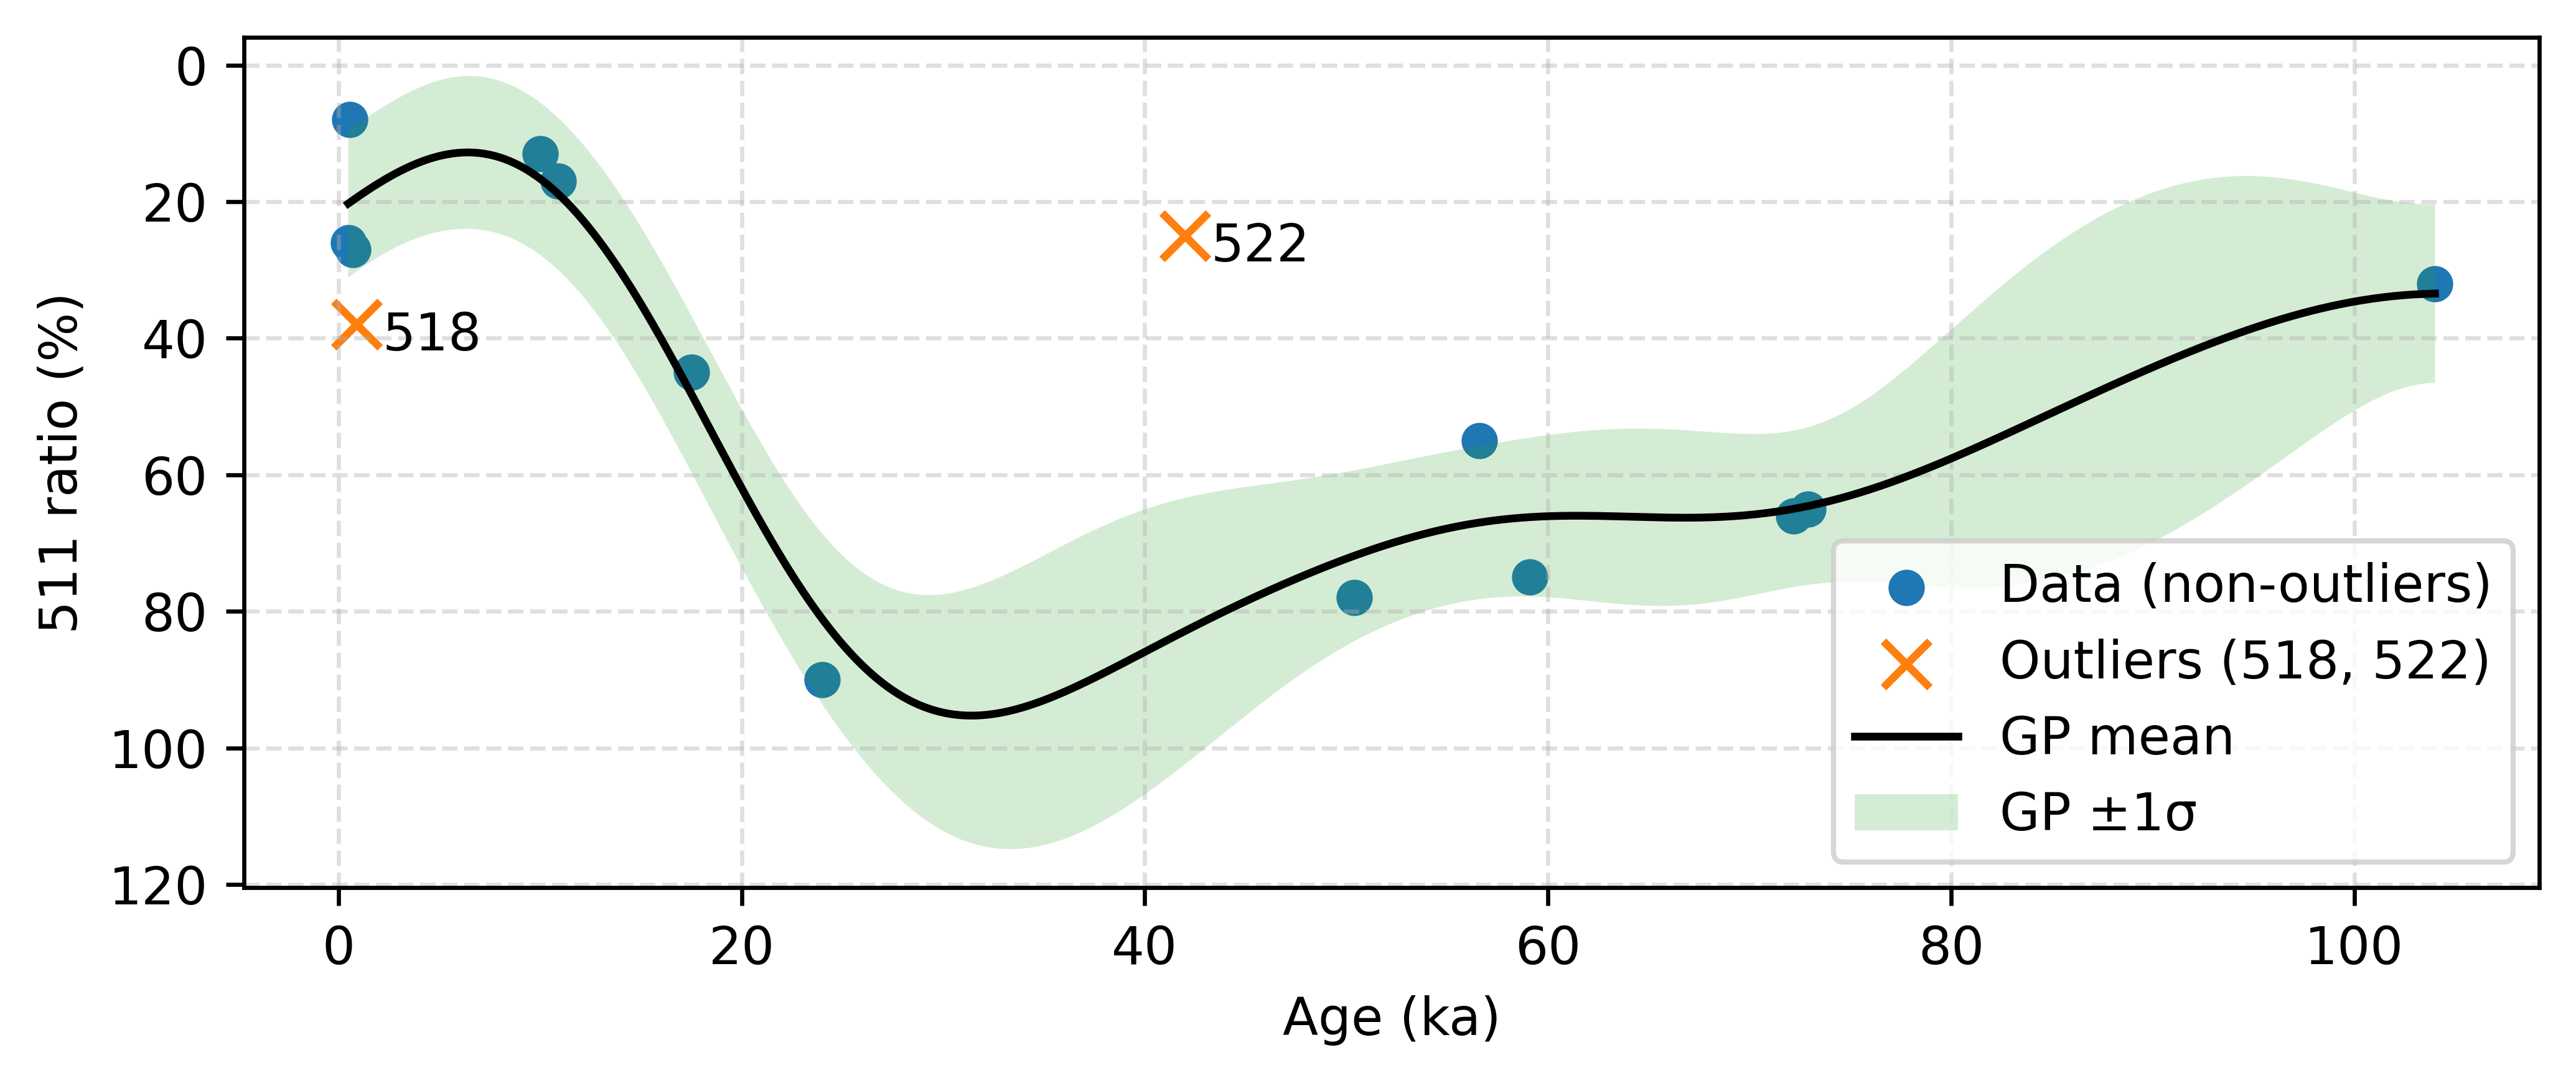

In [ ]:
# Re-run after kernel reset (the environment was cleared).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler

# Data
data = [
    ["T1","CSC-1A","CSC-1(512)",0.49,0.06,26],
    ["T1","JSL-2A","JSL-2A(513)",0.71,0.07,27],
    ["T1","JSL-3A","JSL-3A(514)",0.56,0.07,8],
    ["T2","CBR-1A","CBR-1A(511)",24,1.6,90],
    ["T2","CSC-2A","CSC-2A(515)",17.5,1.1,45],
    ["T2","CSC-3A","CSC-3A(516)",10,0.6,13],
    ["T2","CSC-4A","CSC-4A(517)",10.9,0.7,17],
    ["T2","CSC-5A","CSC-5A(518)",0.9,0.09,38],
    ["T3","KXC-3A","KXC-3A(522)",42,2.8,25],
    ["T3","RJG-1A","RJG-1A(523)",59.1,3.6,75],
    ["T3","HDL-1A","HDL-1A(524)",50.4,4.1,78],
    ["T3","JD-1A","JD-1A(526)",72.2,4.6,66],
    ["T3","JD-2A","JD-2A(527)",72.9,4.7,65],
    ["T3","ALL-1A","ALL-1A(529)",56.6,4.2,55],
    ["T3","MS-1A","MS-1A(530)",104,7,32],
]
columns = ["Geomorphic unit","ID","Lab ID","age(ka)","1 sigma","511 ratio (%)"]
df = pd.DataFrame(data, columns=columns)

# Extract numeric Lab ID
def extract_numeric_lab_id(s):
    m = re.search(r"\((\d+)\)", s)
    return int(m.group(1)) if m else None

df["Lab_ID_num"] = df["Lab ID"].apply(extract_numeric_lab_id)

# Mark outliers (518 and 522)
outlier_ids = {518, 522}
df["is_outlier"] = df["Lab_ID_num"].isin(outlier_ids)

# Use only non-outliers for GP fit
df_fit = df.loc[~df["is_outlier"]].copy().sort_values("age(ka)")

X = df_fit[["age(ka)"]].values
y = df_fit["511 ratio (%)"].values

# Standardize X for numerical stability
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

# Kernel: Constant * RBF + White noise (estimated)
kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF(length_scale=1, length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1, noise_level_bounds=(1e-6, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=8, random_state=0)


gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=12, random_state=0)

gp.fit(Xs, y)

# Predict on a dense grid spanning the non-outlier ages
x_grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
xg_s = scaler.transform(x_grid)
y_mean, y_std = gp.predict(xg_s, return_std=True)

# Prepare outliers
df_out = df.loc[df["is_outlier"]]

# Plot
fig, ax = plt.subplots(figsize=(7, 3),dpi=600)
ax.scatter(df_fit["age(ka)"], df_fit["511 ratio (%)"], marker="o", label="Data (non-outliers)")
ax.scatter(df_out["age(ka)"], df_out["511 ratio (%)"], marker="x", s=80, label="Outliers (518, 522)")

ax.plot(x_grid.ravel(), y_mean, label="GP mean", color='k')
ax.fill_between(x_grid.ravel(), y_mean - y_std, y_mean + y_std, alpha=0.2, label="GP ±1σ")

for _, row in df_out.iterrows():
    ax.annotate(str(row["Lab_ID_num"]), (row["age(ka)"], row["511 ratio (%)"]), xytext=(5, -5), textcoords="offset points")

ax.set_xlabel("Age (ka)")
ax.set_ylabel("511 ratio (%)")
ax.invert_yaxis()
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc='lower right')

plt.tight_layout()

# save the figure as '511_ratio_GP' uder Figures/ as .JPG and .PDF, respectively
fig.savefig(f"Figures/511_ratio_GP.jpg", dpi=600)
fig.savefig(f"Figures/511_ratio_GP.pdf", dpi=600)

plt.show()


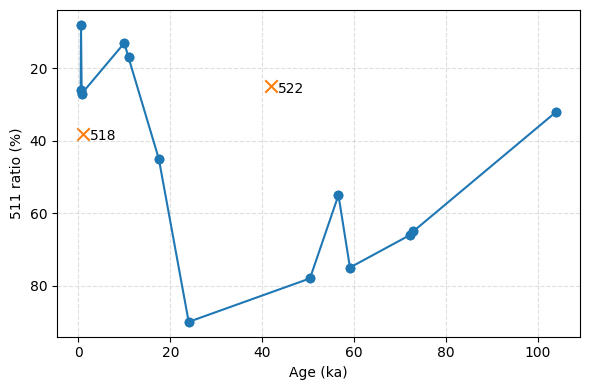

In [3]:
# Create the requested line plot with outliers marked differently.
import pandas as pd
import matplotlib.pyplot as plt
import re

# Prepare the data
data = [
    ["T1","CSC-1A","CSC-1(512)",0.49,0.06,26],
    ["T1","JSL-2A","JSL-2A(513)",0.71,0.07,27],
    ["T1","JSL-3A","JSL-3A(514)",0.56,0.07,8],
    ["T2","CBR-1A","CBR-1A(511)",24,1.6,90],
    ["T2","CSC-2A","CSC-2A(515)",17.5,1.1,45],
    ["T2","CSC-3A","CSC-3A(516)",10,0.6,13],
    ["T2","CSC-4A","CSC-4A(517)",10.9,0.7,17],
    ["T2","CSC-5A","CSC-5A(518)",0.9,0.09,38],
    ["T3","KXC-3A","KXC-3A(522)",42,2.8,25],
    ["T3","RJG-1A","RJG-1A(523)",59.1,3.6,75],
    ["T3","HDL-1A","HDL-1A(524)",50.4,4.1,78],
    ["T3","JD-1A","JD-1A(526)",72.2,4.6,66],
    ["T3","JD-2A","JD-2A(527)",72.9,4.7,65],
    ["T3","ALL-1A","ALL-1A(529)",56.6,4.2,55],
    ["T3","MS-1A","MS-1A(530)",104,7,32],
]

columns = ["Geomorphic unit","ID","Lab ID","age(ka)","1 sigma","511 ratio (%)"]
df = pd.DataFrame(data, columns=columns)

# Extract numeric Lab ID inside parentheses for outlier identification
def extract_numeric_lab_id(s):
    m = re.search(r"\((\d+)\)", s)
    return int(m.group(1)) if m else None

df["Lab_ID_num"] = df["Lab ID"].apply(extract_numeric_lab_id)

# Outliers: Lab ID numbers 518 and 522
outlier_ids = {518, 522}
df["is_outlier"] = df["Lab_ID_num"].isin(outlier_ids)

# Split data
df_non_out = df[~df["is_outlier"]].sort_values(by="age(ka)")
df_out = df[df["is_outlier"]]

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

# Line connecting only non-outliers
ax.plot(df_non_out["age(ka)"], df_non_out["511 ratio (%)"], marker="o", linestyle="-")

# Scatter for outliers (different marker) and non-outliers (for emphasis)
ax.scatter(df_non_out["age(ka)"], df_non_out["511 ratio (%)"], marker="o")
ax.scatter(df_out["age(ka)"], df_out["511 ratio (%)"], marker="x", s=80)

# Annotate outliers with their Lab ID numbers for clarity
for _, row in df_out.iterrows():
    ax.annotate(str(row["Lab_ID_num"]), (row["age(ka)"], row["511 ratio (%)"]), xytext=(5, -5), textcoords="offset points")

# Axes labels
ax.set_xlabel("Age (ka)")
ax.set_ylabel("511 ratio (%)")

# Reverse y-axis
ax.invert_yaxis()

# ax.set_title("Age vs. 511 ratio (%)\n(outliers 518 & 522 shown as 'x' and not connected)")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
